# ML1 Task 2 – Developer salary prediction

---
**Sections:**
1. Setup & data loading
2. Dataset overview
3. Target variable (`annual.pay.usd`)
4. Missing values
5. Numeric features
6. Ordinal features
7. Nominal / categorical features
8. Multi-select (technology stack) features
9. AI adoption features
10. Correlation with target
11. Key findings summary

---
## 1. Setup and  data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 11
})

TRAIN_PATH = 'train.csv'
TARGET     = 'annual.pay.usd'

df = pd.read_csv(TRAIN_PATH)
print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')

Shape: (2512, 41)  (2,512 rows × 41 columns)


---
## 2. Dataset overview

In [ ]:
# Columns
NUMERIC_COLS = ['coding.years.total', 'coding.years.professional', 'experience.years', 'job.satisfaction']

ORDINAL_COLS = [
    'age.group', 'education', 'company.size',
    'tech.purchase.influence', 'ai.sentiment', 'ai.trust',
    'ai.complex.rating', 'daily.search.time', 'daily.answer.time'
]

NOMINAL_COLS = [
    'region', 'employment.type', 'work.location', 'is.dev.professional',
    'dev.role', 'people.manager', 'industry', 'build.vs.buy',
    'cloud.hosting', 'first.help.source', 'uses.ai', 'ai.job.threat'
]

MULTI_SELECT_COLS = [
    'side.coding', 'how.learned.coding', 'prog.languages', 'databases',
    'cloud.platforms', 'web.frameworks', 'other.tech', 'dev.tools',
    'dev.environments', 'personal.os', 'work.os', 'project.mgmt.tools',
    'comm.tools', 'ai.search.tools', 'ai.tools.used'
]

print('Column types:')
print(f'Numeric: {len(NUMERIC_COLS)}')
print(f'Ordinal: {len(ORDINAL_COLS)}')
print(f'Nominal: {len(NOMINAL_COLS)}')
print(f'Multi-select: {len(MULTI_SELECT_COLS)}')
print(f'Target: 1')
print()
df.head(3)

Column types:
  Numeric       : 4
  Ordinal       : 9
  Nominal       : 12
  Multi-select  : 15
  Target        : 1



,annual.pay.usd,region,age.group,employment.type,work.location,education,is.dev.professional,coding.years.total,coding.years.professional,experience.years,...,uses.ai,ai.sentiment,ai.trust,ai.complex.rating,ai.job.threat,daily.search.time,daily.answer.time,cloud.hosting,first.help.source,job.satisfaction
0,44529.0,R11,35-44,Freelance/Self-employed,In-person,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,29.0,16.0,17.0,...,Yes,Indifferent,Somewhat trust,Very poor at handling complex tasks,No,60-120 minutes a day,15-30 minutes a day,Hybrid (on-prem and cloud),Traditional public search engine,7.0
1,82086.0,R05,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,17.0,14.0,13.0,...,"No, and I don't plan to",NaN,NaN,NaN,NaN,30-60 minutes a day,Less than 15 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,6.0
2,14223.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,4.0,0.0,1.0,...,Yes,Very favorable,Neither trust nor distrust,NaN,I'm not sure,NaN,NaN,NaN,NaN,10.0


In [ ]:
# Basic data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   annual.pay.usd             2512 non-null   float64
 1   region                     2512 non-null   object 
 2   age.group                  2512 non-null   object 
 3   employment.type            2512 non-null   object 
 4   work.location              2512 non-null   object 
 5   education                  2512 non-null   object 
 6   is.dev.professional        2512 non-null   object 
 7   coding.years.total         2507 non-null   float64
 8   coding.years.professional  2501 non-null   float64
 9   experience.years           1649 non-null   float64
 10  dev.role                   2510 non-null   object 
 11  company.size               2511 non-null   object 
 12  people.manager             1653 non-null   object 
 13  industry                   1633 non-null   objec

In [ ]:
# Summary statistics for numeric columns and target
df[[TARGET] + NUMERIC_COLS].describe().round(2)

,annual.pay.usd,coding.years.total,coding.years.professional,experience.years,job.satisfaction
count,2512.00,2507.00,2501.00,1649.00,1645.00
mean,49712.96,12.29,8.23,9.08,7.09
std,109616.16,7.66,6.23,6.64,1.92
min,1.00,0.00,0.00,0.00,0.00
25%,16216.75,7.00,4.00,4.00,6.00
50%,40828.50,10.00,7.00,7.00,7.00
75%,65589.25,16.00,11.00,12.00,8.00
max,4773360.00,49.00,40.00,42.00,10.00


---
## 3. Target variable - `annual.pay.usd`

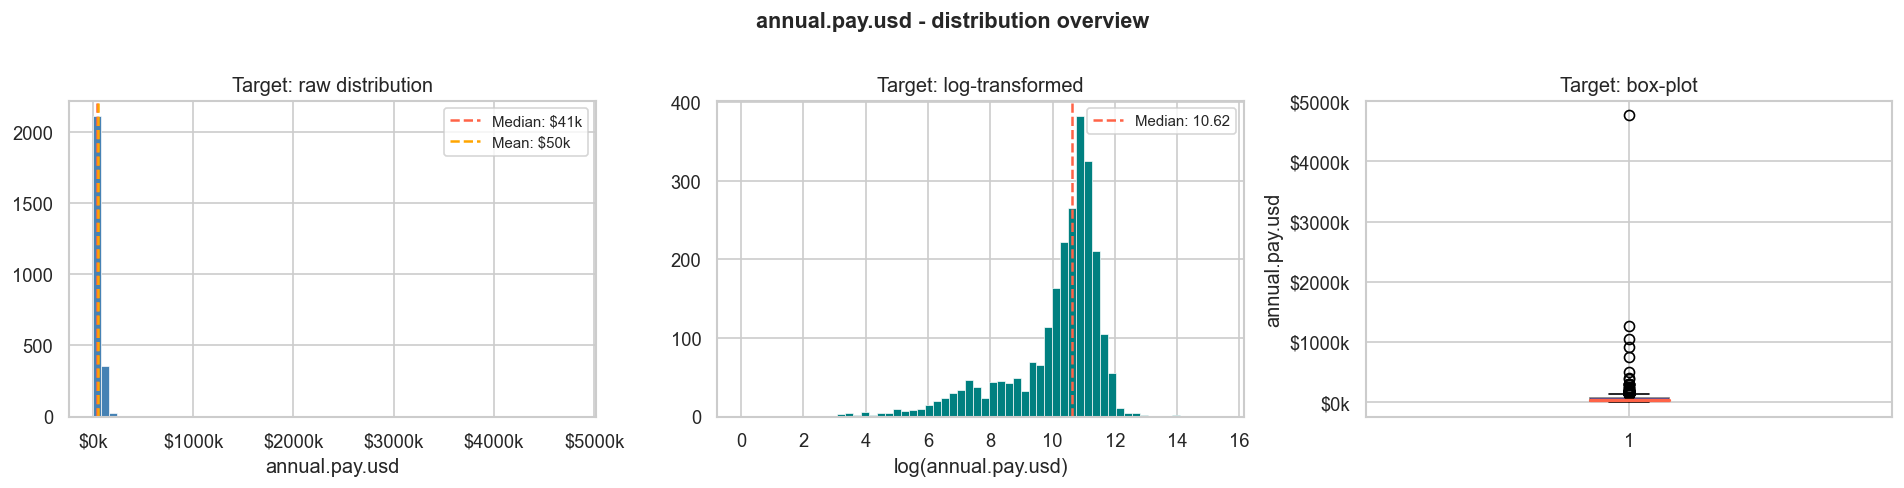

Raw target - skewness: 33.134  |  kurtosis: 1384.799
Log target - skewness: -1.661  |  kurtosis: 3.189

Percentiles:
  P 1: $        98
  P 5: $       834
  P25: $    16,217
  P50: $    40,828
  P75: $    65,589
  P95: $   118,863
  P99: $   177,388


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(df[TARGET].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Target: raw distribution')
axes[0].set_xlabel('annual.pay.usd')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].axvline(df[TARGET].median(), color='tomato', linewidth=1.5, linestyle='--', label=f'Median: ${df[TARGET].median()/1e3:.0f}k')
axes[0].axvline(df[TARGET].mean(),   color='orange',  linewidth=1.5, linestyle='--', label=f'Mean: ${df[TARGET].mean()/1e3:.0f}k')
axes[0].legend(fontsize=9)

# Log-transformed distribution
log_target = np.log(df[TARGET].dropna())
axes[1].hist(log_target, bins=60, color='teal', edgecolor='white', linewidth=0.4)
axes[1].set_title('Target: log-transformed')
axes[1].set_xlabel('log(annual.pay.usd)')
axes[1].axvline(log_target.median(), color='tomato', linewidth=1.5, linestyle='--', label=f'Median: {log_target.median():.2f}')
axes[1].legend(fontsize=9)

# Box-plot (raw) with outlier annotation
axes[2].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='blue', alpha=0.5),
                medianprops=dict(color='tomato', linewidth=2))
axes[2].set_title('Target: box-plot')
axes[2].set_ylabel('annual.pay.usd')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('annual.pay.usd - distribution overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Skewness stats
raw = df[TARGET].dropna()
print(f'Raw target - skewness: {raw.skew():.3f}  |  kurtosis: {raw.kurt():.3f}')
print(f'Log target - skewness: {np.log(raw).skew():.3f}  |  kurtosis: {np.log(raw).kurt():.3f}')
print(f'\nPercentiles:')
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f'  P{p:2d}: ${np.percentile(raw, p):>10,.0f}')

In [ ]:
# Outliers
q01 = df[TARGET].quantile(0.01)
q99 = df[TARGET].quantile(0.99)

print(f'Observations below P1  (< ${q01:,.0f}): {(df[TARGET] < q01).sum()}')
print(f'Observations above P99 (> ${q99:,.0f}): {(df[TARGET] > q99).sum()}')
print()
print('Bottom 10 salaries:')
print(df.nsmallest(10, TARGET)[[TARGET, 'region', 'employment.type', 'dev.role']].to_string())
print()
print('Top 10 salaries:')
print(df.nlargest(10, TARGET)[[TARGET, 'region', 'employment.type', 'dev.role']].to_string())

Observations below P1  (< $98): 26
Observations above P99 (> $177,388): 26

Bottom 10 salaries:
      annual.pay.usd region employment.type                                       dev.role
232              1.0    R17       Full-time                            Developer, back-end
1652            11.0    R17       Full-time                          Developer, QA or test
250             15.0    R17       Full-time                            Developer, back-end
1959            21.0    R17       Full-time                           Developer, front-end
312             25.0    R11       Full-time                          Developer, full-stack
396             25.0    R17       Full-time                          Developer, full-stack
1553            26.0    R17       Full-time                    Developer, game or graphics
288             31.0    R17       Full-time                          Developer, QA or test
371             33.0    R17       Full-time  Developer, desktop or enterprise applica

---
## 4. Missing values

In [ ]:
# Missing value summary
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(miss_df)} / {df.shape[1]}')
print()
print(miss_df.to_string())

Columns with missing values: 32 / 41

                           missing_n  missing_pct
cloud.hosting                    900         35.8
daily.answer.time                888         35.4
daily.search.time                886         35.3
first.help.source                883         35.2
industry                         879         35.0
job.satisfaction                 867         34.5
experience.years                 863         34.4
people.manager                   859         34.2
other.tech                       853         34.0
ai.tools.used                    850         33.8
ai.complex.rating                781         31.1
ai.trust                         771         30.7
web.frameworks                   581         23.1
cloud.platforms                  554         22.1
ai.search.tools                  485         19.3
ai.sentiment                     444         17.7
ai.job.threat                    443         17.6
databases                        306         12.2
project.mgmt

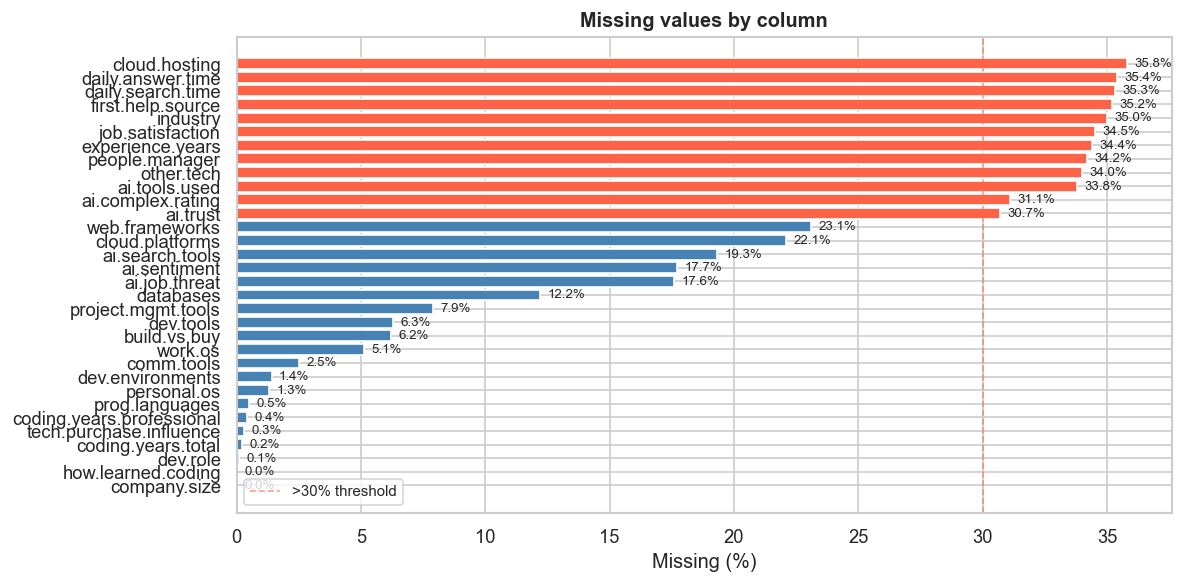

In [ ]:
# Missing values bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if p > 30 else 'blue' for p in miss_df['missing_pct']]
bars = ax.barh(miss_df.index, miss_df['missing_pct'], color=colors, edgecolor='white')
ax.axvline(30, color='tomato', linestyle='--', linewidth=1, alpha=0.6, label='>30% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values by column', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, pct in zip(bars, miss_df['missing_pct']):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# For columns with >5% missing, check if those with vs without data earn differently
high_miss_cols = miss_df[miss_df['missing_pct'] > 5].index.tolist()
high_miss_cols = [c for c in high_miss_cols if c in df.columns and c != TARGET]

print('Median salary - present vs missing rows:')
print(f'{"Column":<30} {"Present (median $)":>22} {"Missing (median $)":>22} {"Diff %":>10}')
print('-' * 90)
for col in high_miss_cols[:12]:
    m_present = df.loc[df[col].notna(), TARGET].median()
    m_missing = df.loc[df[col].isna(),  TARGET].median()
    if pd.notna(m_present) and pd.notna(m_missing) and m_present != 0:
        diff = (m_missing - m_present) / m_present * 100
        print(f'{col:<30} {m_present:>22,.0f} {m_missing:>22,.0f} {diff:>+10.1f}%')

Median salary — present vs missing rows:
Column                             Present (median $)     Missing (median $)     Diff %
------------------------------------------------------------------------------------------
cloud.hosting                                  43,226                 36,450      -15.7%
daily.answer.time                              42,925                 36,607      -14.7%
daily.search.time                              42,816                 36,719      -14.2%
first.help.source                              42,951                 36,470      -15.1%
industry                                       43,044                 36,429      -15.4%
job.satisfaction                               42,865                 36,653      -14.5%
experience.years                               42,899                 36,561      -14.8%
people.manager                                 42,865                 36,653      -14.5%
other.tech                                     42,766               

---
## 5. Numeric features

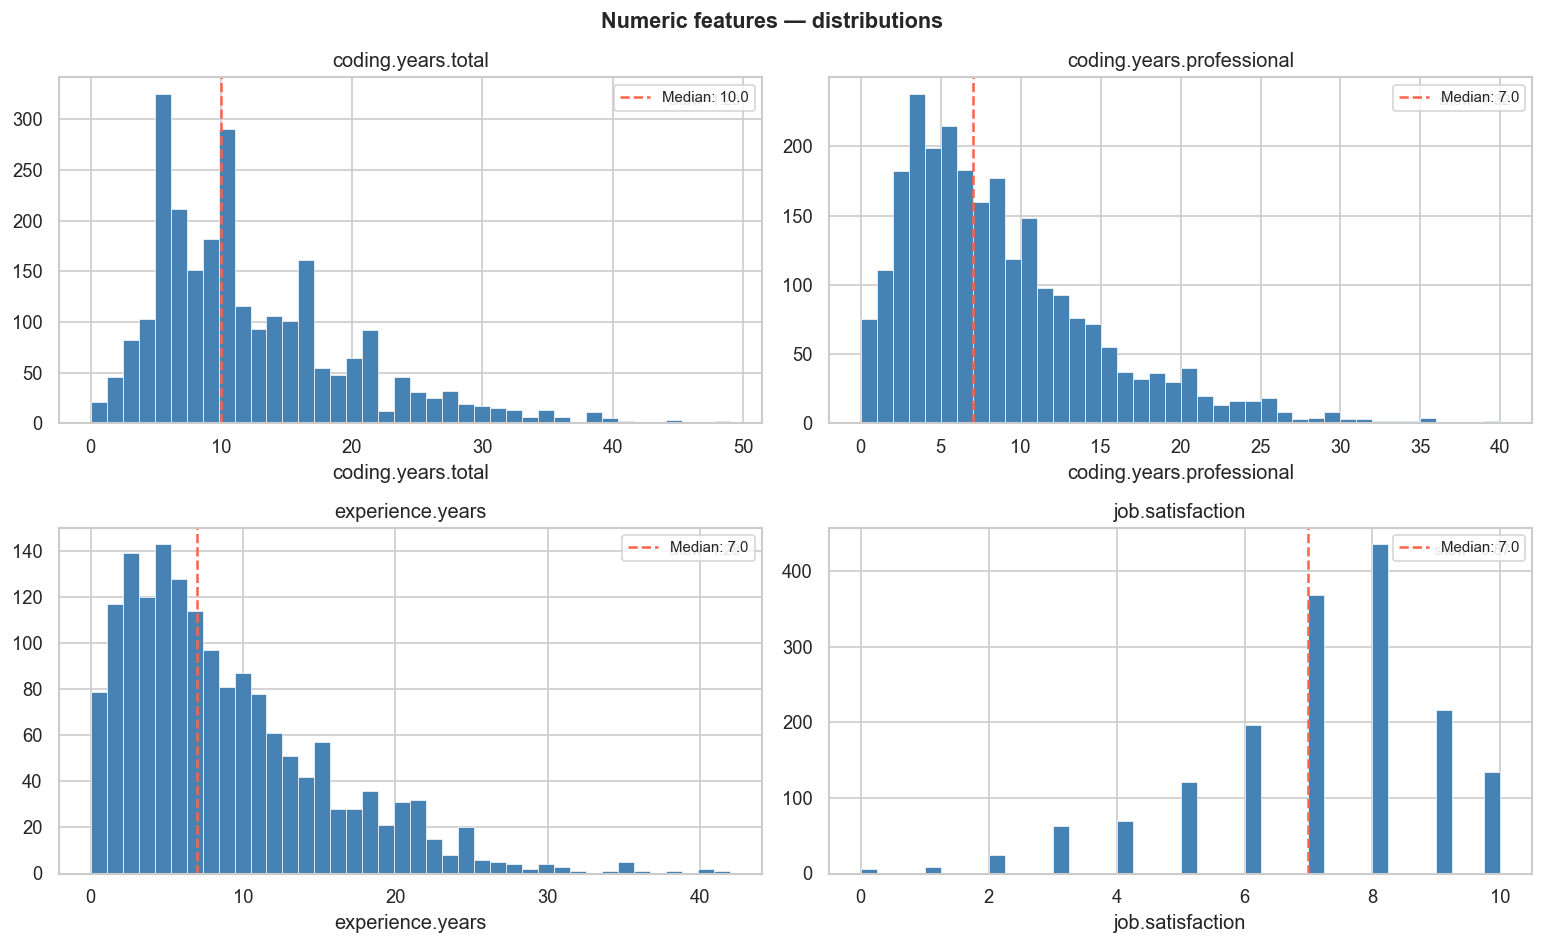

In [ ]:
# Distributions of numeric features
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='blue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(data.median(), color='tomato', linewidth=1.5,
                    linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=9)
    axes[i].annotate(f'skew={data.skew():.2f}', xy=(0.97, 0.92),
                     xycoords='axes fraction', ha='right', fontsize=9, color='gray')

plt.suptitle('Numeric features - distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

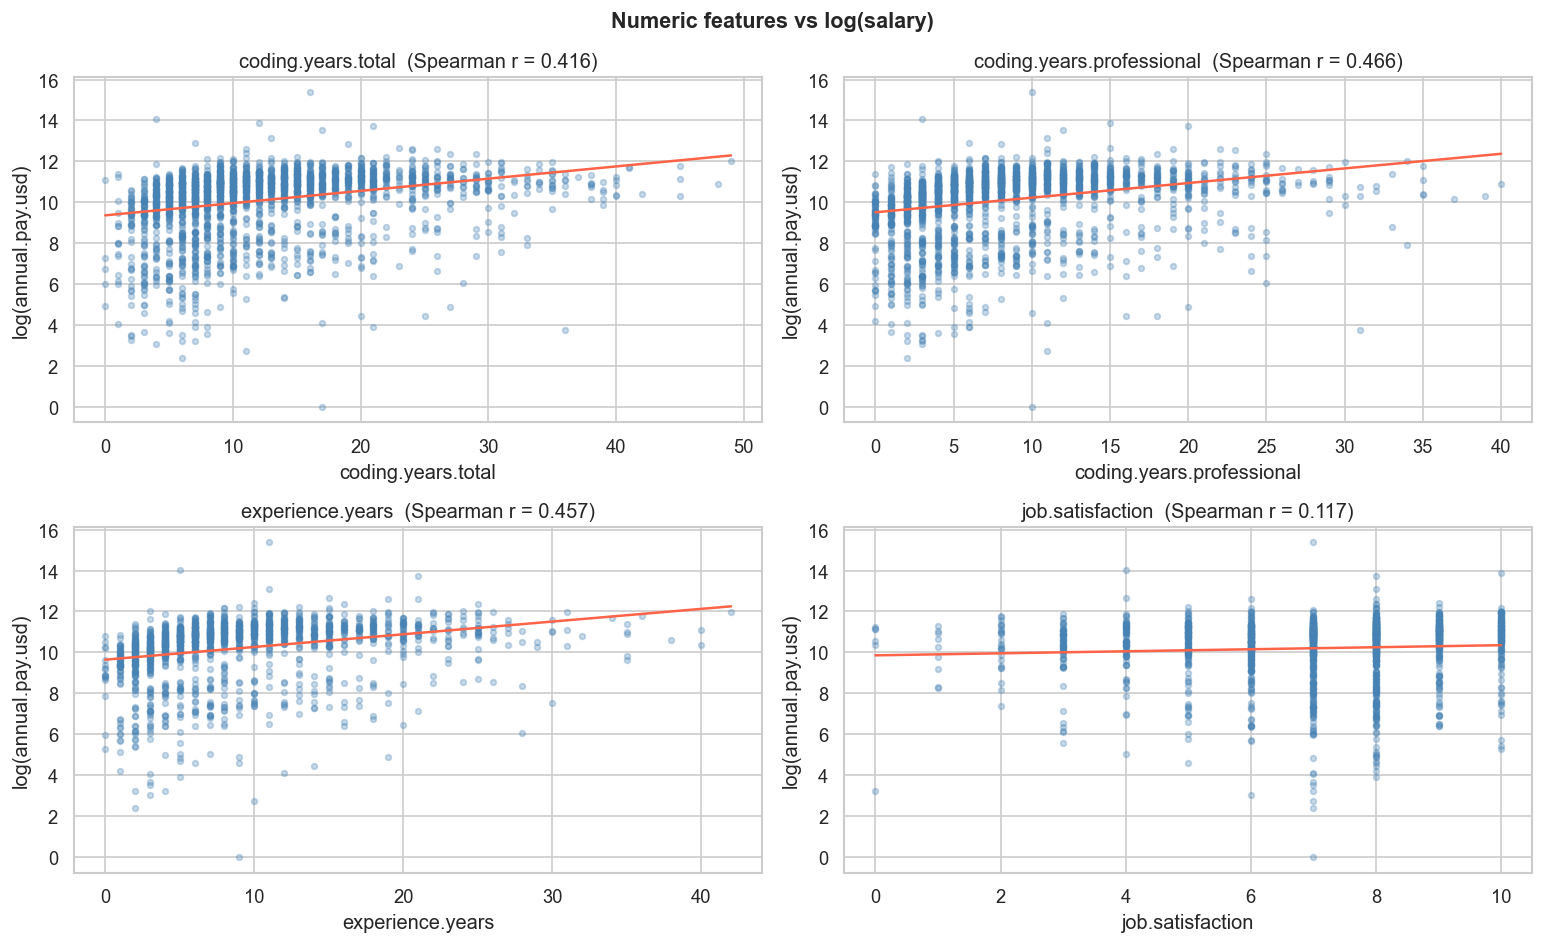

In [ ]:
# Scatter plots vs log(target)
log_y = np.log(df[TARGET])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    mask = df[col].notna() & df[TARGET].notna()
    x = df.loc[mask, col]
    y = log_y[mask]
    axes[i].scatter(x, y, alpha=0.3, s=12, color='blue')
    # trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xline, p(xline), color='tomato', linewidth=1.5)
    corr = x.corr(y, method='spearman')
    axes[i].set_title(f'{col}  (Spearman r = {corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(annual.pay.usd)')

plt.suptitle('Numeric features vs log(salary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

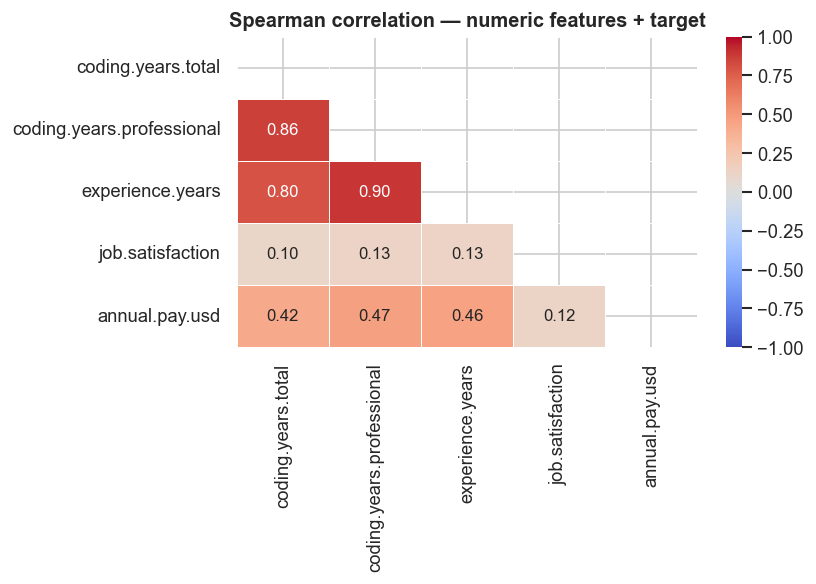


Note: coding.years.total and coding.years.professional are likely highly correlated.
Consider using their difference as an engineered feature.


In [ ]:
# Correlation heatmap among numeric columns
num_df = df[NUMERIC_COLS + [TARGET]].copy()
corr_matrix = num_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Spearman correlation - numeric features + target', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNote: coding.years.total and coding.years.professional are likely highly correlated.')
print('Consider using their difference as an engineered feature.')

---
## 6. Ordinal features

In [ ]:
# Ordinal encodings we will use in modeling
ORDINAL_MAPS = {
    'age.group': {
        '18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4
    },
    'education': {
        'Primary/elementary school': 0,
        'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
        'Some college/university study without earning a degree': 2,
        'Associate degree (A.A., A.S., etc.)': 3,
        'Something else': 3,
        'Bachelor\'s degree (B.A., B.S., B.Eng., etc.)': 4,
        'Master\'s degree (M.A., M.S., M.Eng., MBA, etc.)': 5,
        'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6
    },
    'company.size': {
        'Just me - I am a freelancer, sole proprietor, etc.': 0,
        '2 to 9 employees': 1,
        '10 to 19 employees': 2,
        '20 to 99 employees': 3,
        '100 to 499 employees': 4,
        '500 to 999 employees': 5,
        '1,000 to 4,999 employees': 6,
        '5,000 to 9,999 employees': 7,
        '10,000 or more employees': 8
    },
    'tech.purchase.influence': {
        'I have little or no influence': 0,
        'I have some influence': 1,
        'I have a great deal of influence': 2
    },
    'ai.sentiment': {
        'Very unfavorable': 0, 'Unfavorable': 1, 'Indifferent': 2,
        'Unsure': 2, 'Favorable': 3, 'Very favorable': 4
    },
    'ai.trust': {
        'Highly distrust': 0, 'Somewhat distrust': 1,
        'Neither trust nor distrust': 2,
        'Somewhat trust': 3, 'Highly trust': 4
    },
    'ai.complex.rating': {
        'Very poor at handling complex tasks': 0,
        'Bad at handling complex tasks': 1,
        'Neither good or bad at handling complex tasks': 2,
        'Good, but not great at handling complex tasks': 3,
        'Very well at handling complex tasks': 4
    },
    'daily.search.time': {
        'Less than 15 minutes a day': 0,
        '15-30 minutes a day': 1,
        '30-60 minutes a day': 2,
        '60-120 minutes a day': 3,
        'Over 120 minutes a day': 4
    },
    'daily.answer.time': {
        'Less than 15 minutes a day': 0,
        '15-30 minutes a day': 1,
        '30-60 minutes a day': 2,
        '60-120 minutes a day': 3,
        'Over 120 minutes a day': 4
    }
}

print('Ordinal encodings defined for', len(ORDINAL_MAPS), 'columns.')

Ordinal encodings defined for 9 columns.


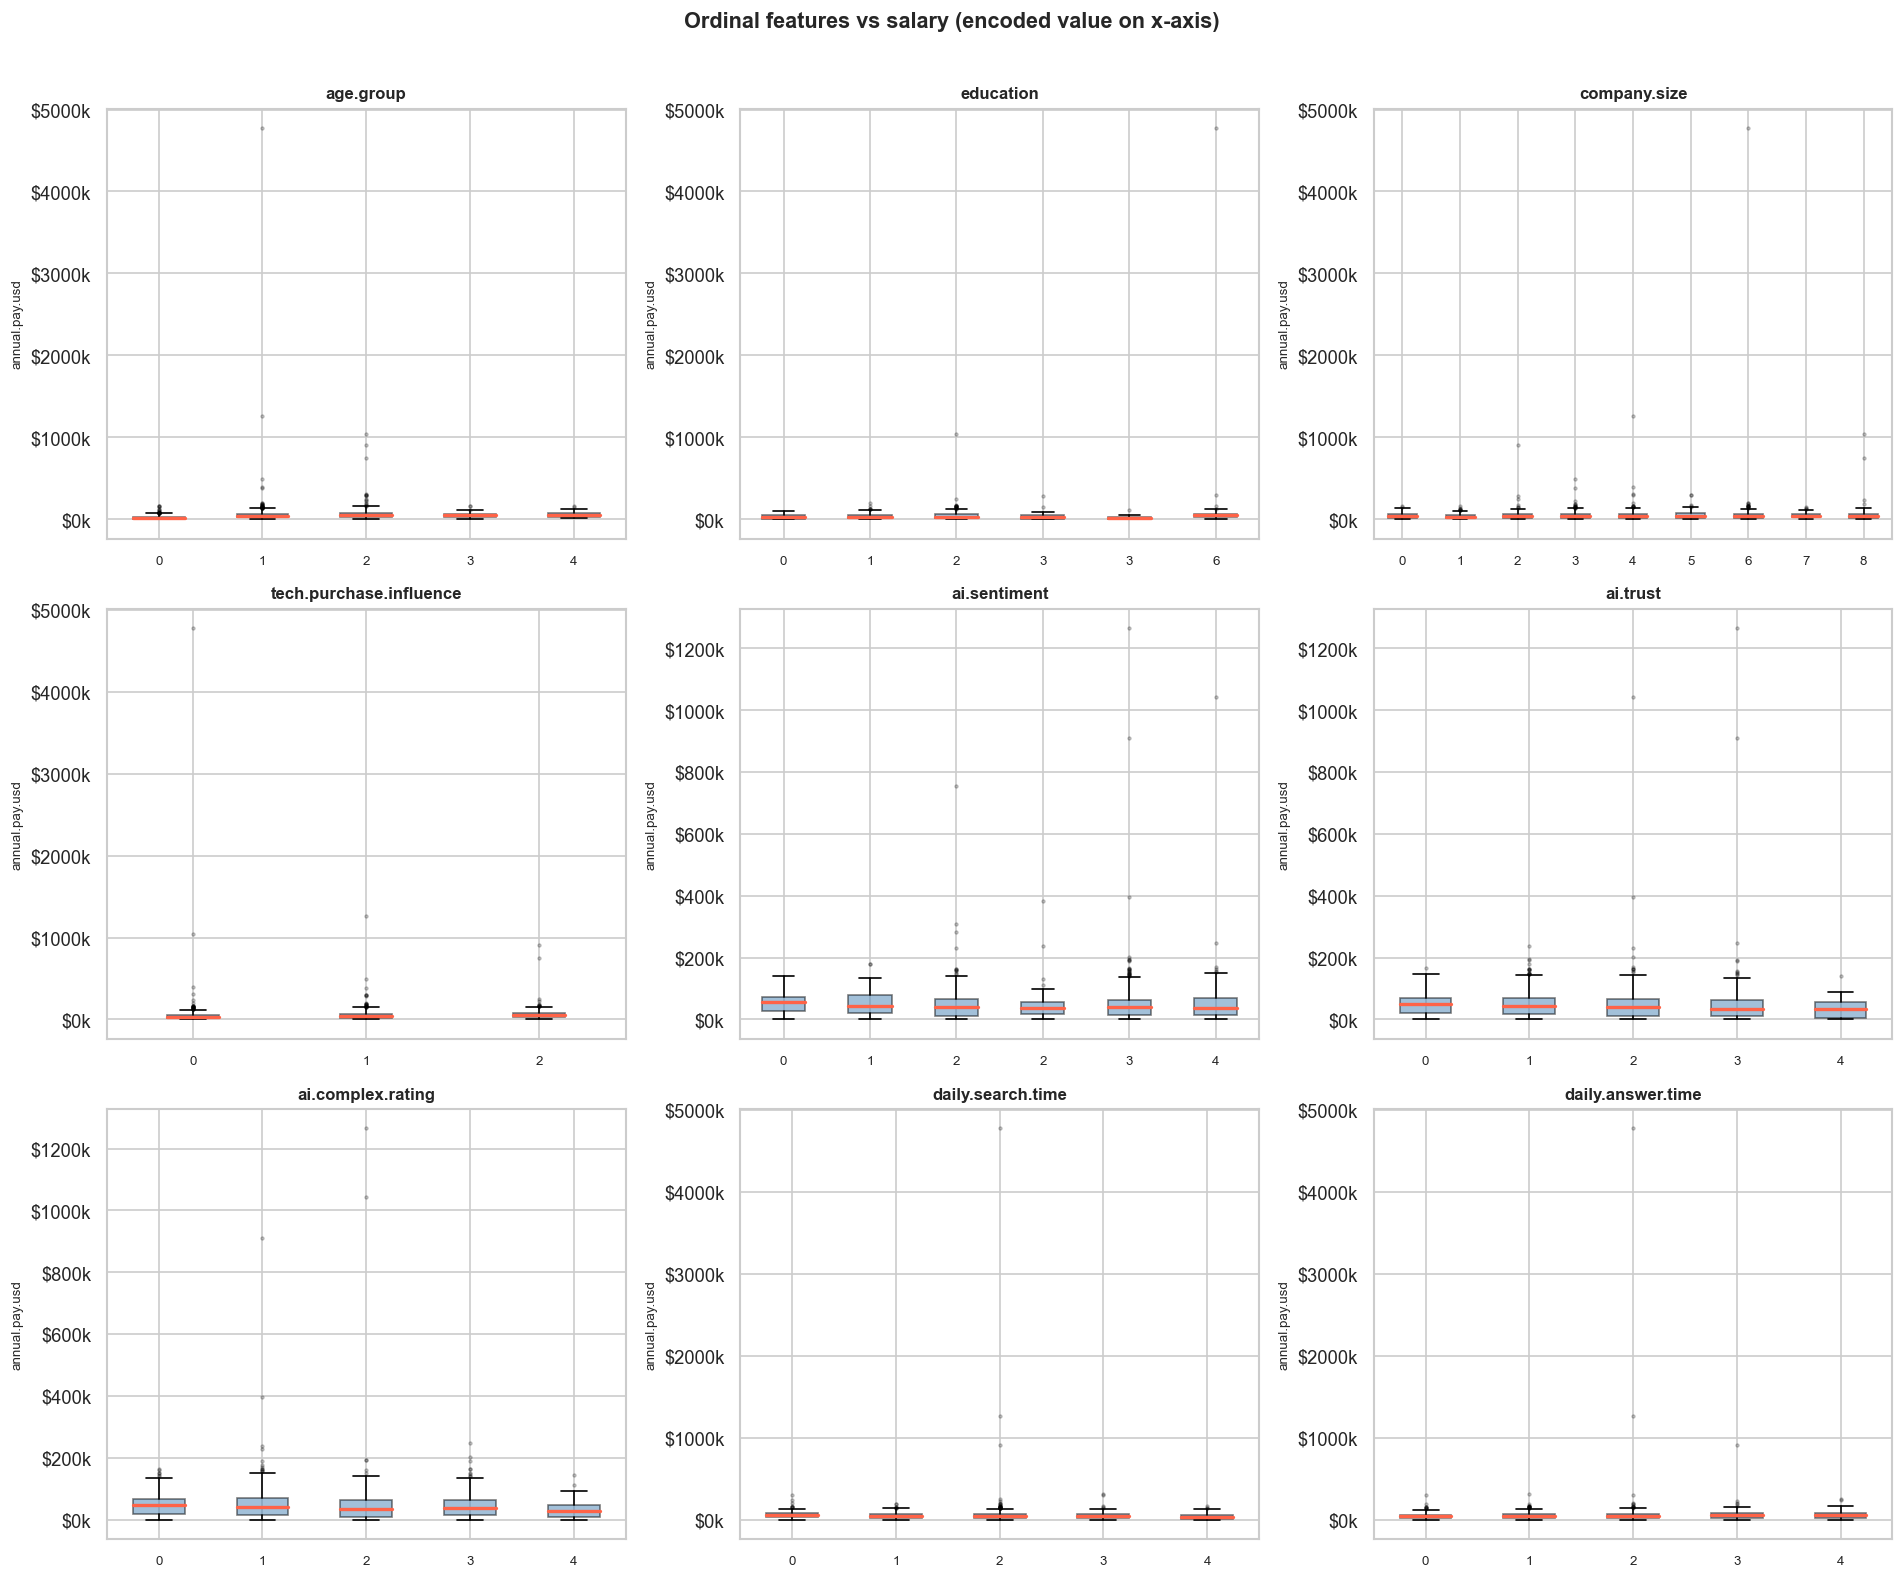

In [14]:
# ── Box-plots: ordinal feature vs salary ─────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(ORDINAL_MAPS.keys()):
    ax = axes[i]
    order = list(ORDINAL_MAPS[col].keys())
    # shorten long labels
    short_labels = [str(ORDINAL_MAPS[col][k]) + ':' + str(k)[:20] for k in order]
    present = [k for k in order if k in df[col].values]
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in present]
    ax.boxplot(data_list, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels([str(ORDINAL_MAPS[col][k]) for k in present], fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('annual.pay.usd', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Ordinal features vs salary (encoded value on x-axis)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# ── Spearman correlation of encoded ordinals with target ──────────────────────
print('Spearman correlation with annual.pay.usd:')
print(f'{"Column":<30} {"Spearman r":>12}')
print('-' * 44)

for col, mapping in ORDINAL_MAPS.items():
    enc = df[col].map(mapping)
    corr = enc.corr(df[TARGET], method='spearman')
    print(f'{col:<30} {corr:>12.4f}')

Spearman correlation with annual.pay.usd:
Column                           Spearman r
--------------------------------------------
age.group                            0.2967
education                            0.0616
company.size                         0.0861
tech.purchase.influence              0.1383
ai.sentiment                        -0.0066
ai.trust                            -0.0795
ai.complex.rating                   -0.0718
daily.search.time                   -0.0840
daily.answer.time                    0.1230


---
## 7. Nominal / categorical features

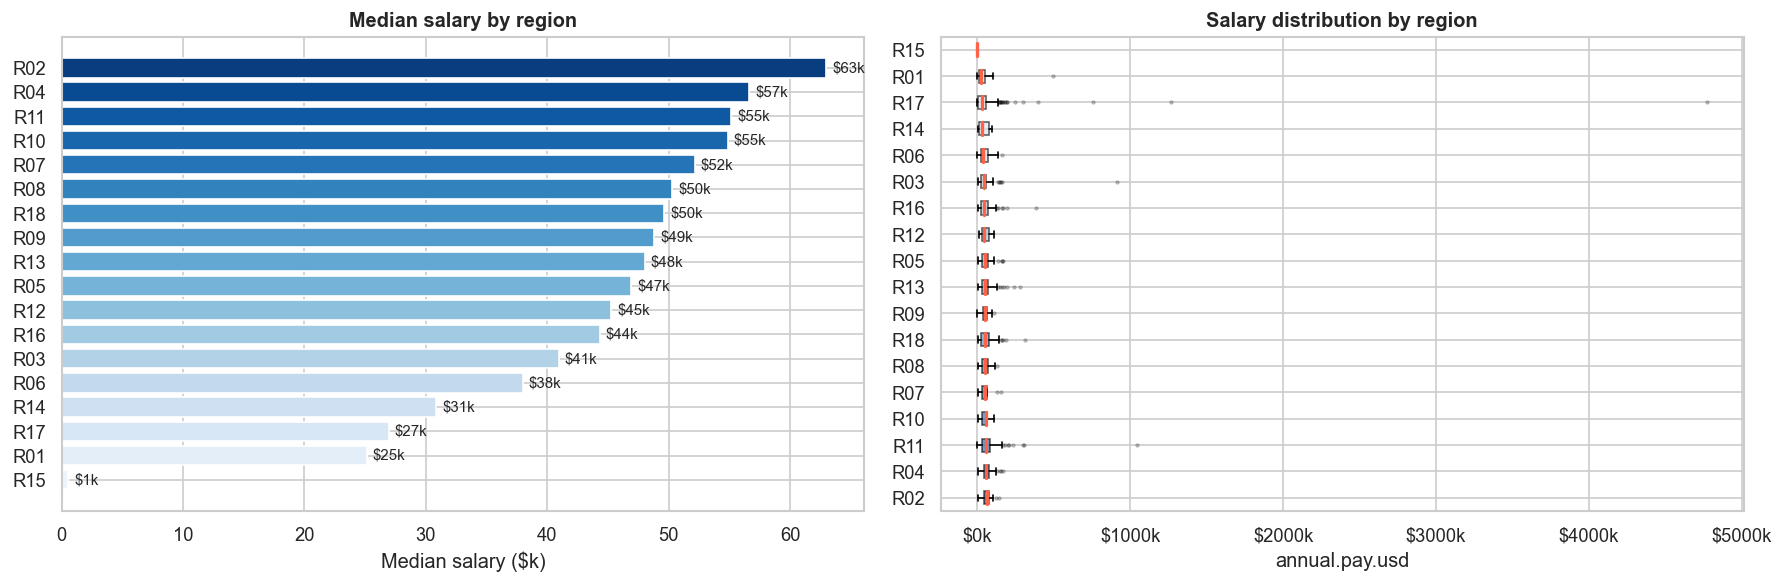


Region summary:
        median_salary   mean_salary  count
region                                    
R02           62965.0  60835.738095     42
R04           56653.0  62285.616667     60
R11           55155.0  63109.085450    433
R10           54868.5  50978.666667      6
R07           52139.5  58900.000000     10
R08           50284.0  50714.824561     57
R18           49654.5  56833.893443    122
R09           48821.0  49855.677966     59
R13           48023.5  54801.084906    212
R05           46913.5  50368.500000     80
R12           45278.0  50968.766667     30
R16           44334.0  60246.750000     60
R03           40937.5  51486.675439    114
R06           37977.0  45936.626667     75
R14           30870.0  42340.692308     13
R17           26930.5  41102.259928   1108
R01           25131.5  46716.066667     30
R15             537.0    537.000000      1


In [ ]:
# Region is the most important nominal feature
region_stats = df.groupby('region')[TARGET].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
region_stats.columns = ['median_salary', 'mean_salary', 'count']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Median salary by region
colors = sns.color_palette('Blues_r', n_colors=len(region_stats))
axes[0].barh(region_stats.index, region_stats['median_salary'] / 1e3, color=colors, edgecolor='white')
axes[0].set_xlabel('Median salary ($k)')
axes[0].set_title('Median salary by region', fontweight='bold')
axes[0].invert_yaxis()
for y, val in zip(range(len(region_stats)), region_stats['median_salary']):
    axes[0].text(val/1e3 + 0.5, y, f'${val/1e3:.0f}k', va='center', fontsize=9)

# Box-plots by region
region_order = region_stats.index.tolist()
data_by_region = [df.loc[df['region'] == r, TARGET].dropna() for r in region_order]
bp = axes[1].boxplot(data_by_region, vert=False, patch_artist=True,
                     medianprops=dict(color='tomato', linewidth=2),
                     flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_yticks(range(1, len(region_order)+1))
axes[1].set_yticklabels(region_order)
axes[1].set_xlabel('annual.pay.usd')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].set_title('Salary distribution by region', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRegion summary:')
print(region_stats.to_string())

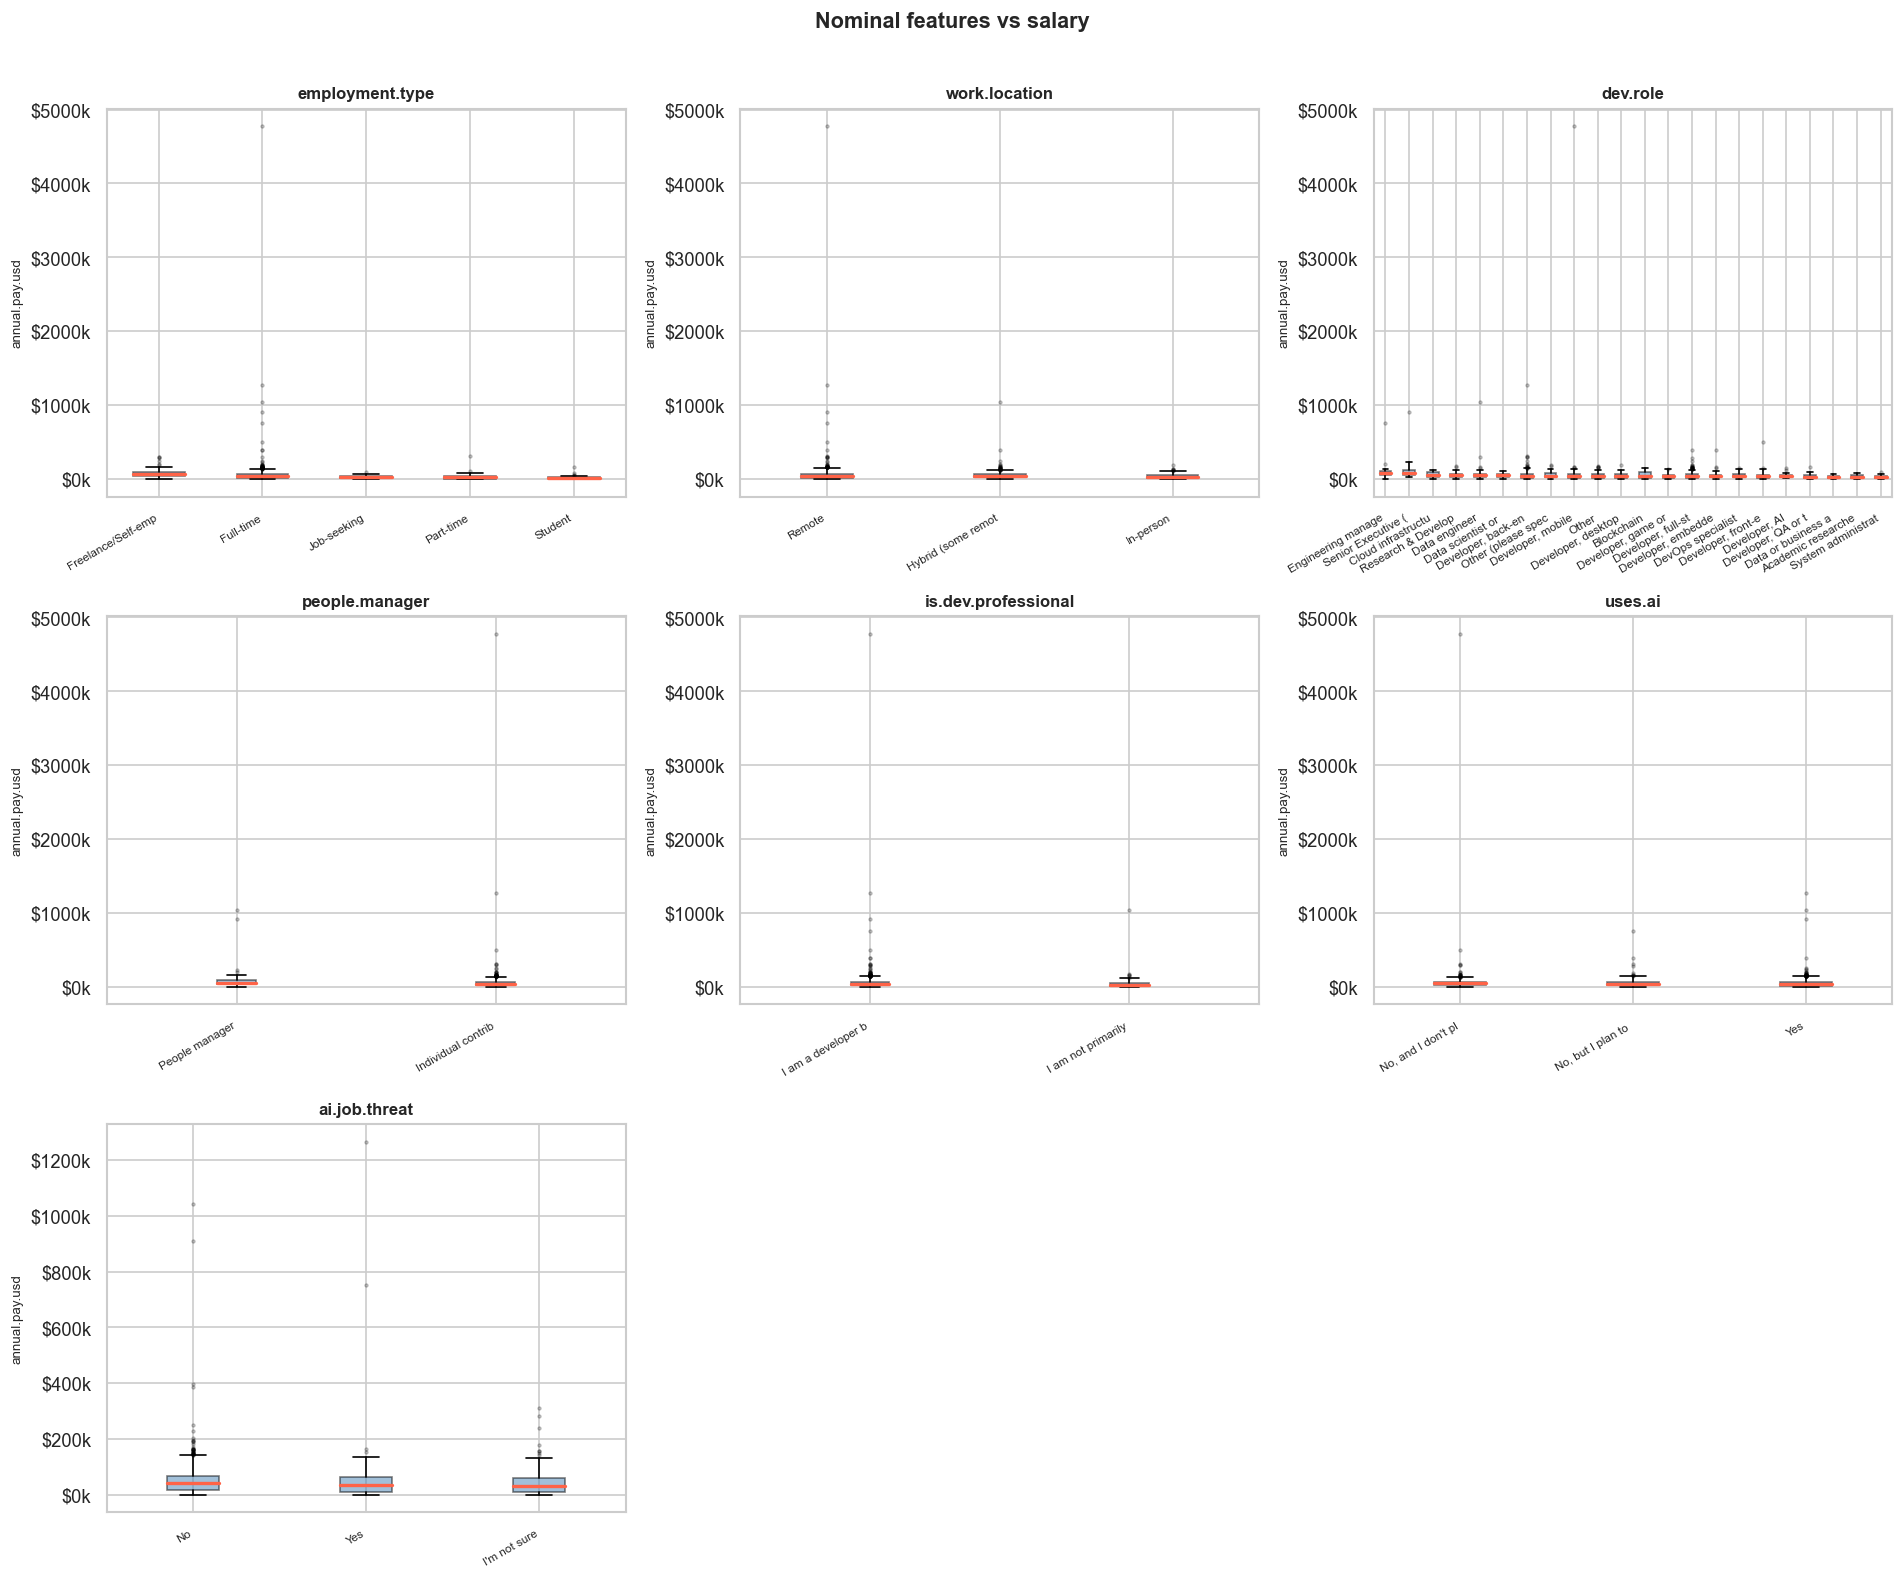

In [ ]:
# Other nominal features vs salary
nominal_to_plot = ['employment.type', 'work.location', 'dev.role', 'people.manager',
                   'is.dev.professional', 'uses.ai', 'ai.job.threat']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(nominal_to_plot):
    ax = axes[i]
    order = (df.groupby(col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in order]
    bp = ax.boxplot(data_list, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5),
                    medianprops=dict(color='tomato', linewidth=2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.3))
    short_labels = [str(k)[:18] for k in order]
    ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('annual.pay.usd', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# hide unused subplots
for j in range(len(nominal_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Nominal features vs salary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

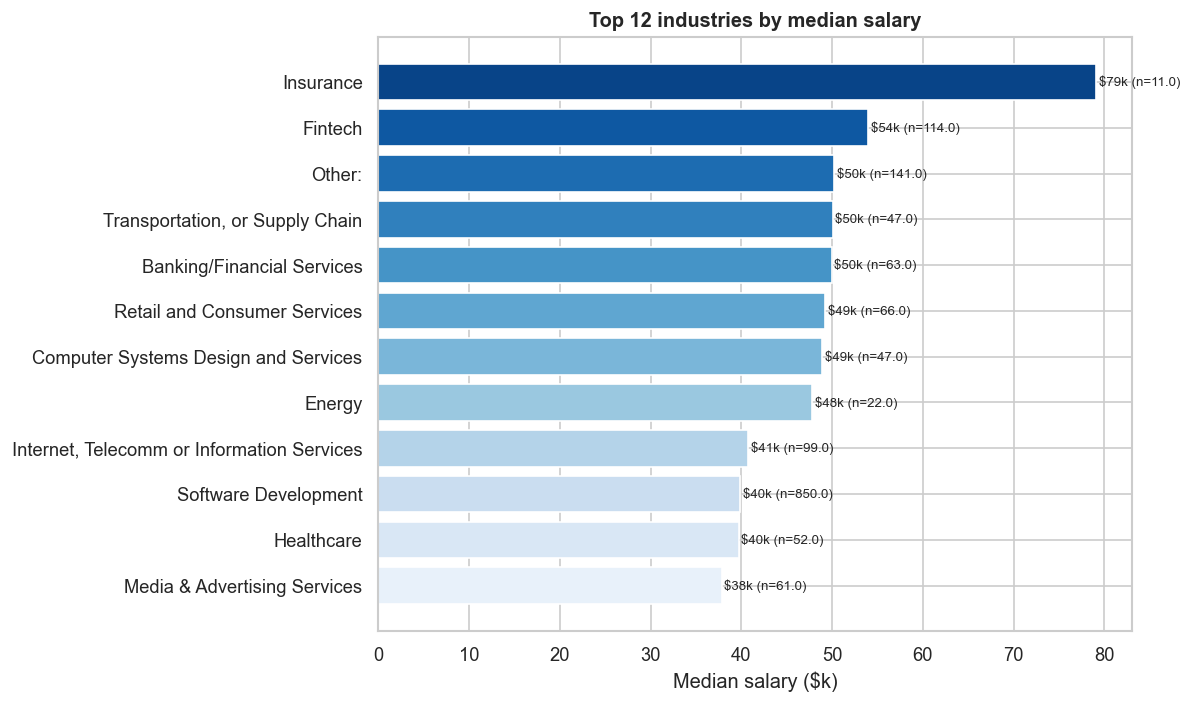

In [ ]:
# Industry: too many categories - show top/bottom 10 by median salary
industry_stats = (df.groupby('industry')[TARGET]
                    .agg(['median', 'count'])
                    .sort_values('median', ascending=False))
top_n = 12
plot_df = industry_stats.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df.index, plot_df['median'] / 1e3,
        color=sns.color_palette('Blues_r', n_colors=top_n), edgecolor='white')
ax.set_xlabel('Median salary ($k)')
ax.set_title(f'Top {top_n} industries by median salary', fontweight='bold')
ax.invert_yaxis()
for y, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['median']/1e3 + 0.3, y, f'${row["median"]/1e3:.0f}k (n={row["count"]})',
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Multi-select (technology stack) features

In [19]:
def parse_multiselect(series, sep=';'):
    """Expand a semicolon-separated column into a list of all individual items."""
    items = []
    for val in series.dropna():
        items.extend([x.strip() for x in str(val).split(sep)])
    return Counter(items)

def multiselect_salary_analysis(df, col, top_n=15, target=TARGET):
    """For each top item in a multi-select column, compute median salary."""
    item_salaries = {}
    for _, row in df.iterrows():
        if pd.isna(row[col]) or pd.isna(row[target]):
            continue
        for item in str(row[col]).split(';'):
            item = item.strip()
            if item not in item_salaries:
                item_salaries[item] = []
            item_salaries[item].append(row[target])
    result = {
        k: {'count': len(v), 'median': np.median(v), 'mean': np.mean(v)}
        for k, v in item_salaries.items() if len(v) >= 10
    }
    return pd.DataFrame(result).T.sort_values('median', ascending=False).head(top_n)

print('Helper functions defined.')

Helper functions defined.


In [ ]:
# Unique item counts per multi-select column
print(f'{"Column":<30} {"Missing%":>10} {"Unique items":>15} {"Avg per row":>12}')
print('-' * 70)

for col in MULTI_SELECT_COLS:
    missing_pct = df[col].isna().mean() * 100
    counter = parse_multiselect(df[col])
    n_unique = len(counter)
    avg_per_row = np.mean([len(str(v).split(';')) for v in df[col].dropna()])
    print(f'{col:<30} {missing_pct:>9.1f}% {n_unique:>15} {avg_per_row:>12.1f}')

Column                           Missing%    Unique items  Avg per row
----------------------------------------------------------------------
side.coding                          0.0%               8          1.9
how.learned.coding                   0.0%               9          3.4
prog.languages                       0.5%              40          4.6
databases                           12.2%              29          3.2
cloud.platforms                     22.1%              25          2.2
web.frameworks                      23.1%              34          3.3
other.tech                          34.0%              37          2.6
dev.tools                            6.3%              34          4.4
dev.environments                     1.4%              33          3.2
personal.os                          1.3%              17          2.0
work.os                              5.1%              14          1.8
project.mgmt.tools                   7.9%              24          2.8
comm.t

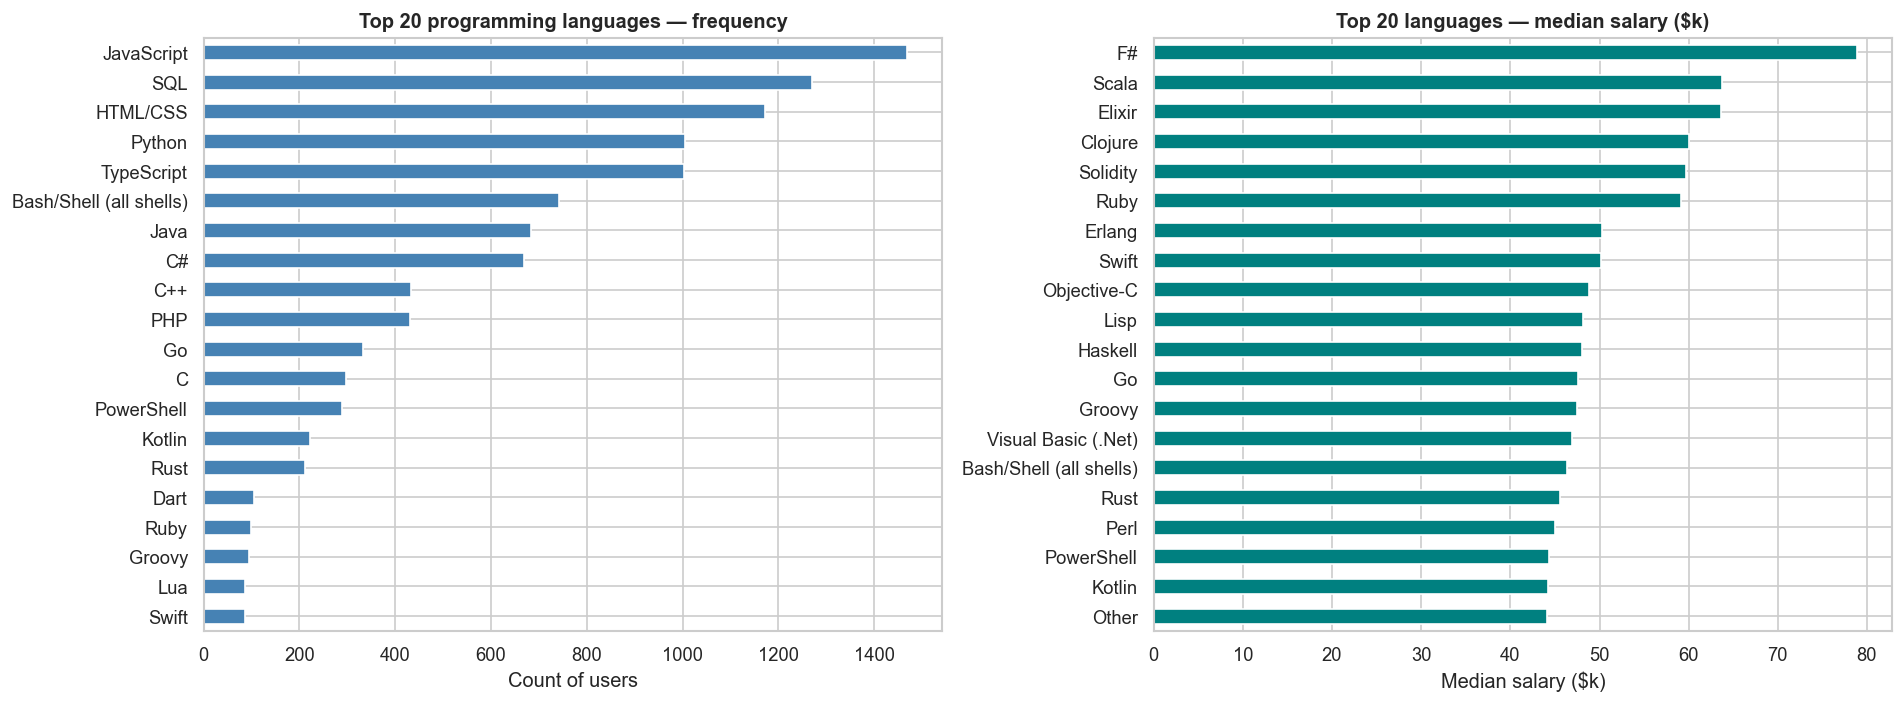

In [ ]:
# Programming languages: frequency + median salary
col = 'prog.languages'
top_n = 20

lang_freq  = parse_multiselect(df[col])
lang_sal   = multiselect_salary_analysis(df, col, top_n=top_n)

# Keep only languages in top_n by frequency too
top_langs = [k for k, _ in lang_freq.most_common(top_n)]
lang_sal_top = multiselect_salary_analysis(df, col, top_n=top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency
top20_lang = pd.Series(dict(lang_freq.most_common(top_n)))
top20_lang.sort_values(ascending=True).plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top {top_n} programming languages — frequency', fontweight='bold')
axes[0].set_xlabel('Count of users')

# Median salary
lang_sal_top.sort_values('median', ascending=True)['median'].div(1e3).plot.barh(
    ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title(f'Top {top_n} languages — median salary ($k)', fontweight='bold')
axes[1].set_xlabel('Median salary ($k)')

plt.tight_layout()
plt.show()

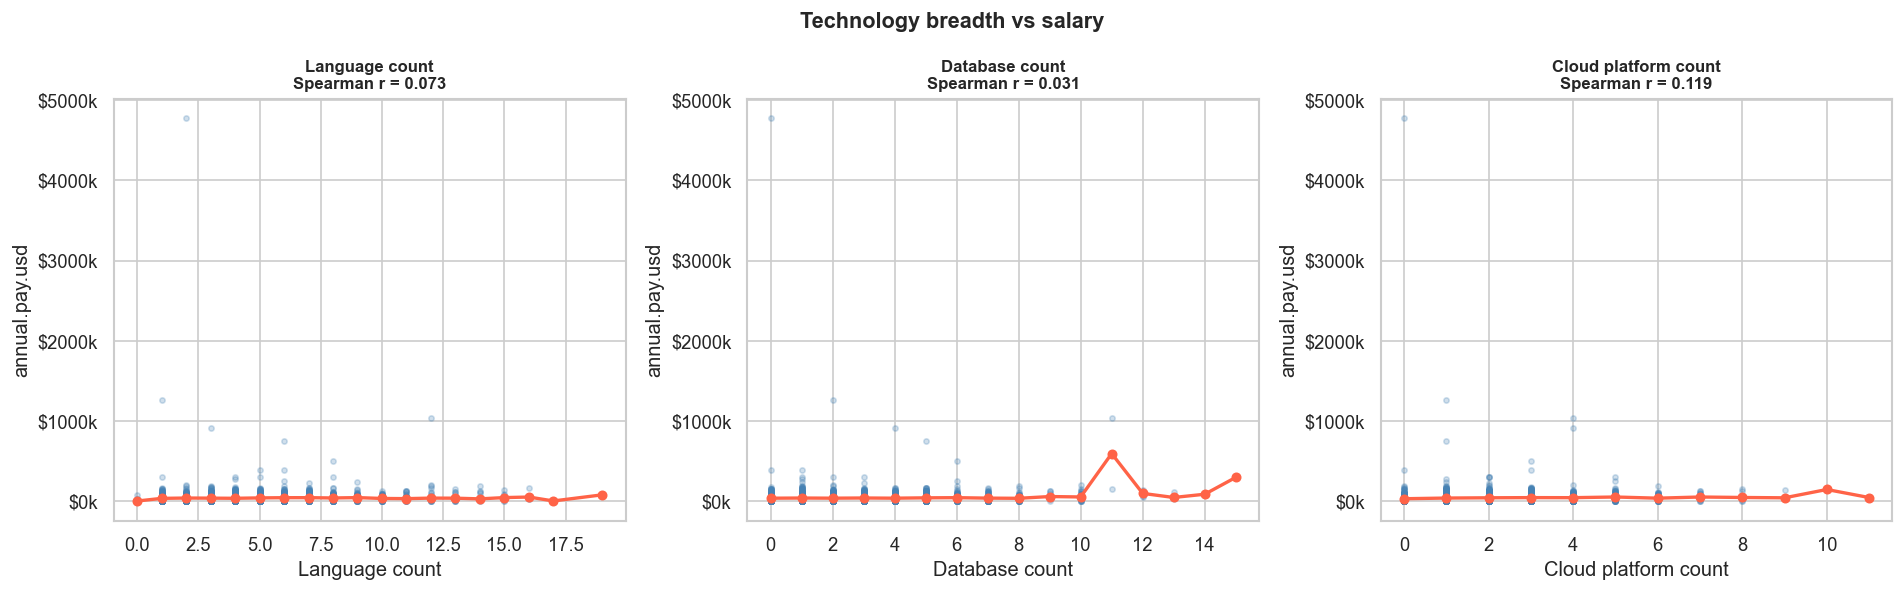

In [ ]:
# Technology count vs salary: do polyglots earn more?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

count_cols = {
    'prog.languages': 'Language count',
    'databases':      'Database count',
    'cloud.platforms':'Cloud platform count'
}

for ax, (col, label) in zip(axes, count_cols.items()):
    counts = df[col].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    mask = df[TARGET].notna()
    ax.scatter(counts[mask], df.loc[mask, TARGET], alpha=0.25, s=10, color='steelblue')
    # bin medians
    tmp = pd.DataFrame({'cnt': counts[mask], 'sal': df.loc[mask, TARGET]})
    binned = tmp.groupby('cnt')['sal'].median()
    ax.plot(binned.index, binned.values, color='tomato', linewidth=2, marker='o', markersize=5)
    corr = counts[mask].corr(df.loc[mask, TARGET], method='spearman')
    ax.set_title(f'{label}\nSpearman r = {corr:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('annual.pay.usd')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Technology breadth vs salary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

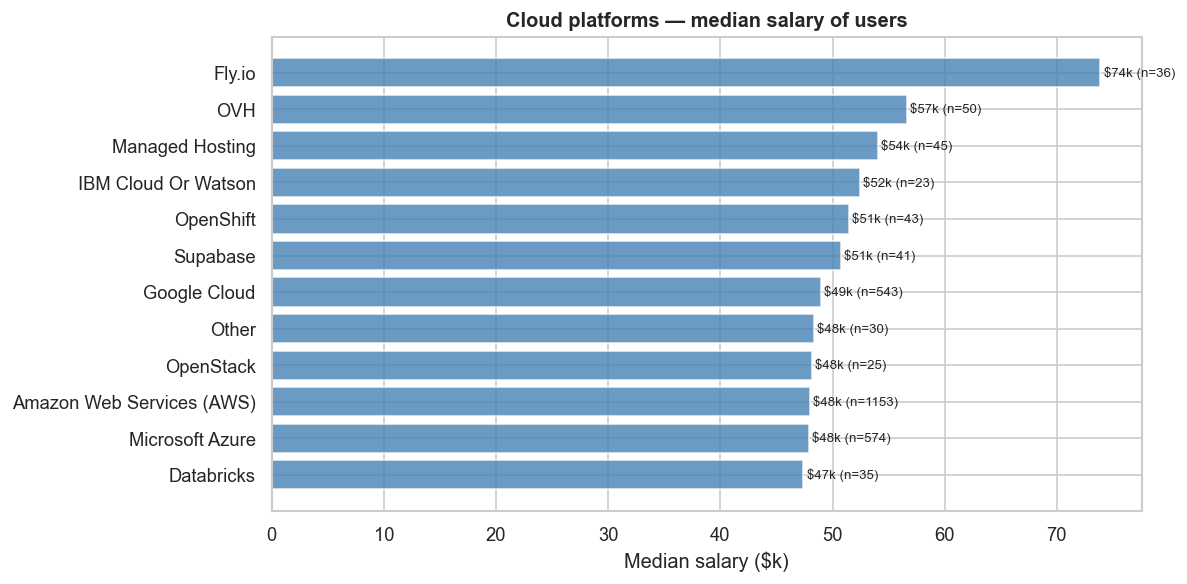

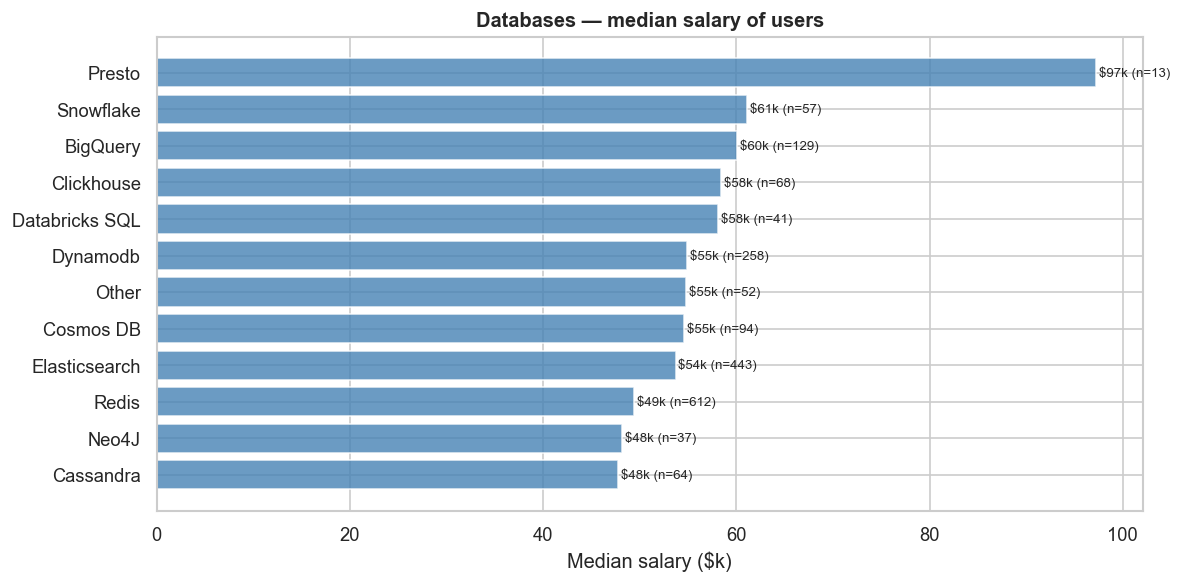

In [ ]:
# Cloud platforms and databases: salary by adoption
for col, title in [('cloud.platforms', 'Cloud platforms'), ('databases', 'Databases')]:
    top_n = 12
    sal_df = multiselect_salary_analysis(df, col, top_n=top_n)

    fig, ax = plt.subplots(figsize=(10, 5))
    sal_df_sorted = sal_df.sort_values('median')
    bars = ax.barh(sal_df_sorted.index, sal_df_sorted['median'] / 1e3,
                   color='steelblue', edgecolor='white', alpha=0.8)
    for bar, (_, row) in zip(bars, sal_df_sorted.iterrows()):
        ax.text(row['median']/1e3 + 0.3, bar.get_y() + bar.get_height()/2,
                f'${row["median"]/1e3:.0f}k (n={int(row["count"])})', va='center', fontsize=8)
    ax.set_xlabel('Median salary ($k)')
    ax.set_title(f'{title} — median salary of users', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 9. AI adoption features

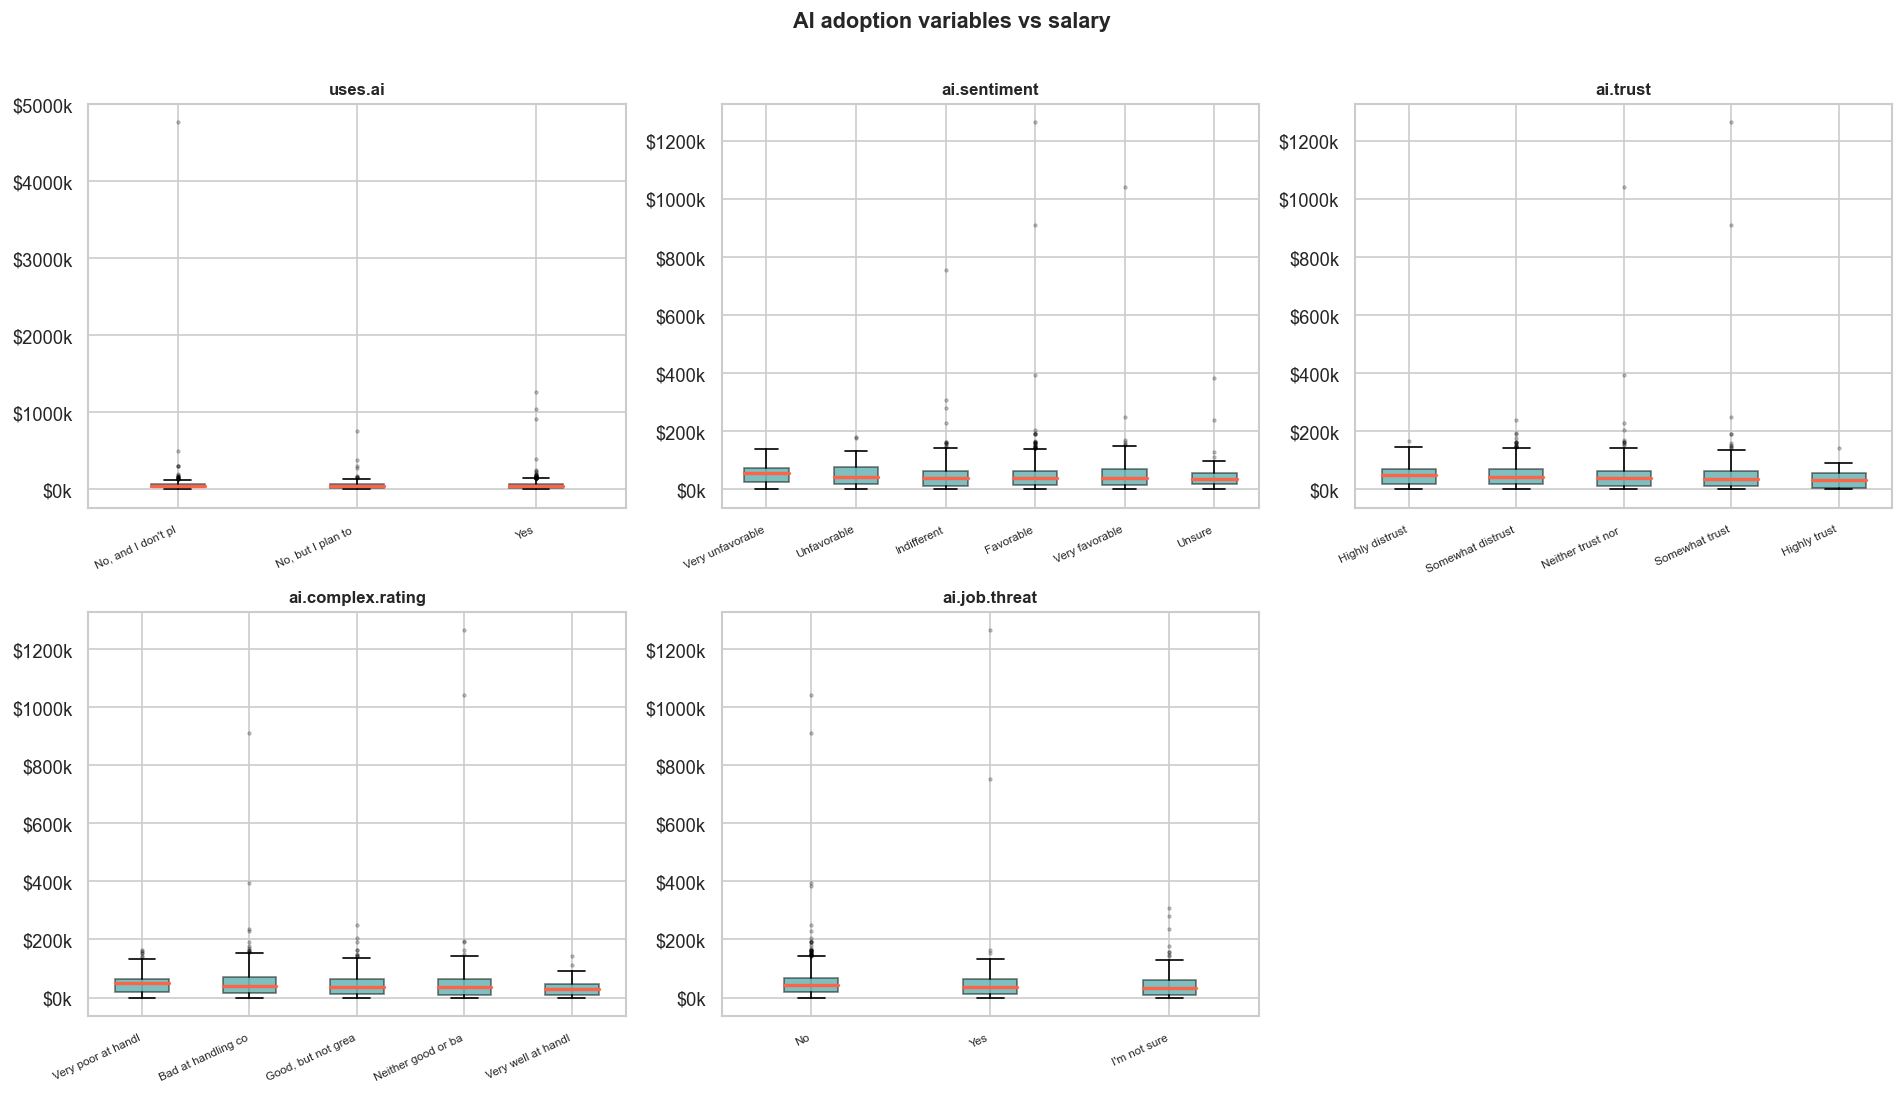

In [ ]:
# AI tool adoption vs salary
ai_cols = ['uses.ai', 'ai.sentiment', 'ai.trust', 'ai.complex.rating', 'ai.job.threat']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(ai_cols):
    ax = axes[i]
    order = (df.groupby(col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in order]
    ax.boxplot(data_list, patch_artist=True,
               boxprops=dict(facecolor='teal', alpha=0.5),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels([str(k)[:18] for k in order], rotation=25, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

axes[-1].set_visible(False)
plt.suptitle('AI adoption variables vs salary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

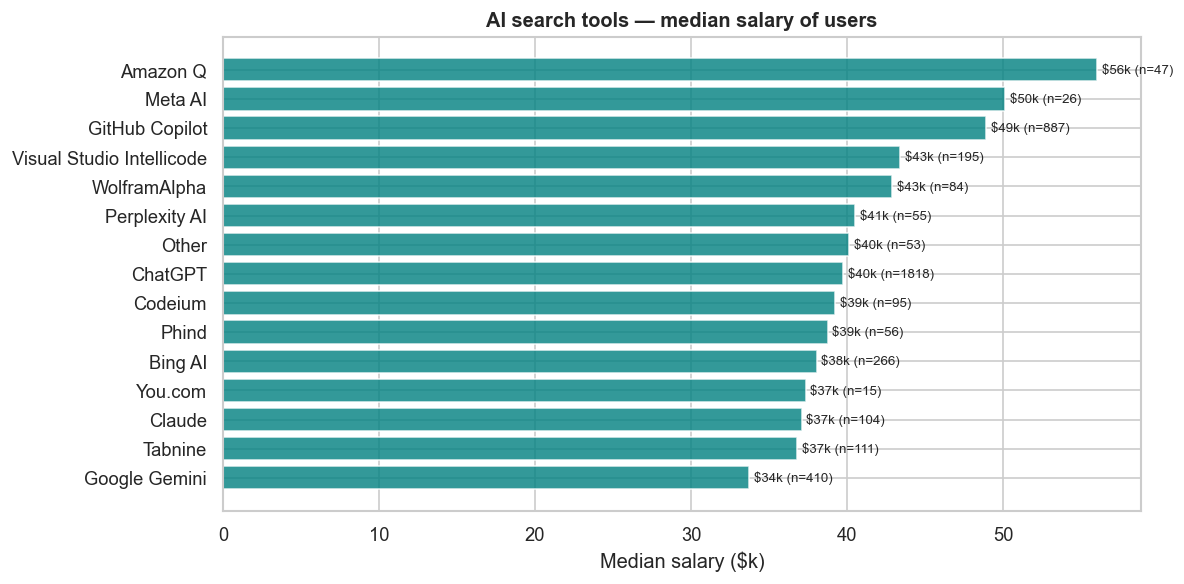

In [ ]:
# AI search tools: which tools' users earn most?
ai_sal = multiselect_salary_analysis(df, 'ai.search.tools', top_n=15)

fig, ax = plt.subplots(figsize=(10, 5))
ai_sal_sorted = ai_sal.sort_values('median')
ax.barh(ai_sal_sorted.index, ai_sal_sorted['median'] / 1e3,
        color='teal', edgecolor='white', alpha=0.8)
for y, (_, row) in enumerate(ai_sal_sorted.iterrows()):
    ax.text(row['median']/1e3 + 0.3, y, f'${row["median"]/1e3:.0f}k (n={int(row["count"])})',
            va='center', fontsize=8)
ax.set_xlabel('Median salary ($k)')
ax.set_title('AI search tools — median salary of users', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Overall correlation with target

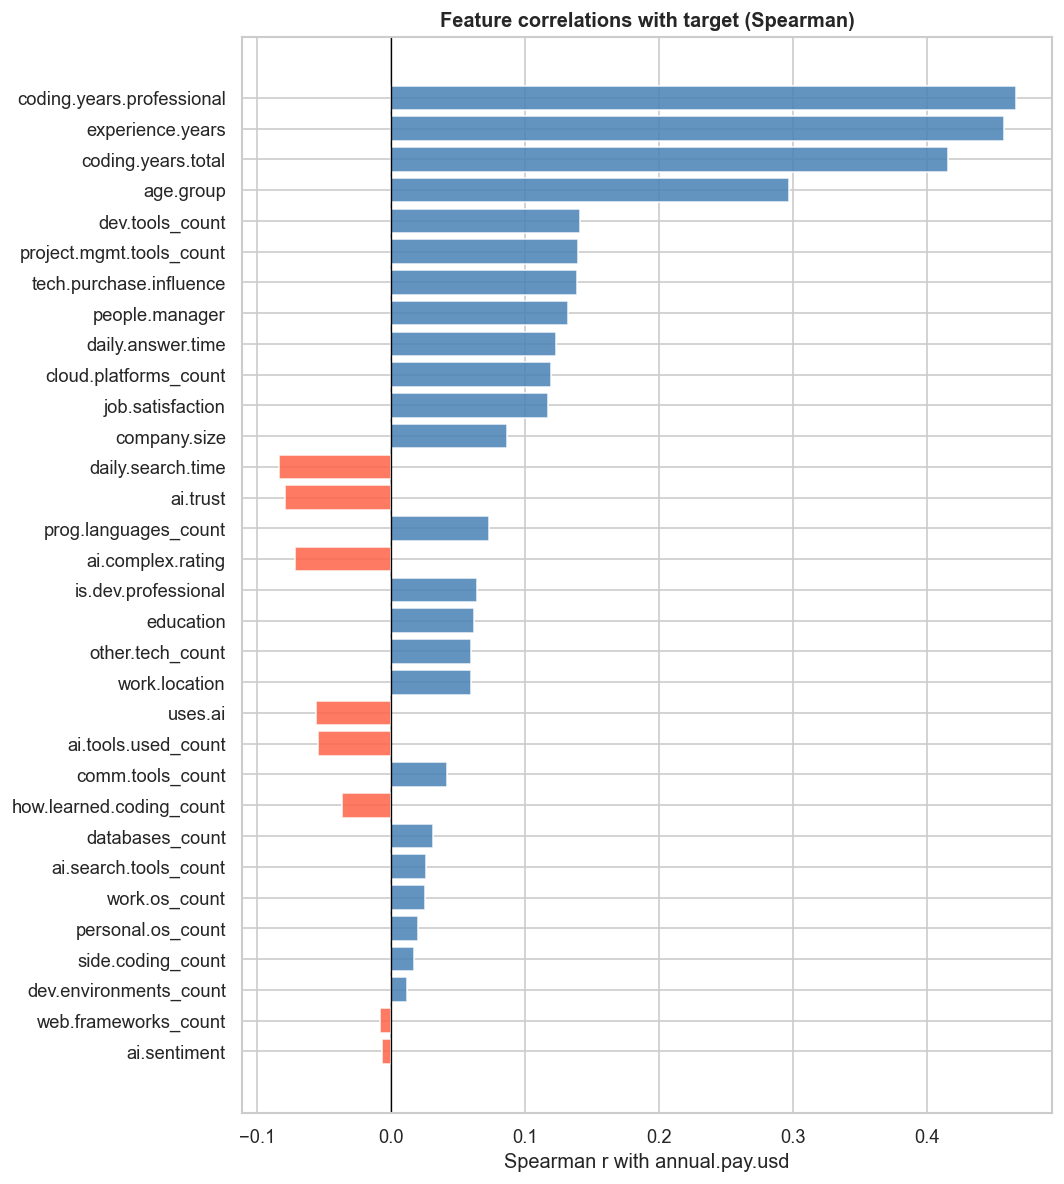


Top 15 features by |Spearman r|:
                  feature               type  spearman_r
coding.years.professional            numeric    0.465885
         experience.years            numeric    0.457414
       coding.years.total            numeric    0.415511
                age.group            ordinal    0.296734
          dev.tools_count multi_select_count    0.141083
 project.mgmt.tools_count multi_select_count    0.139435
  tech.purchase.influence            ordinal    0.138287
           people.manager     binary/nominal    0.131603
        daily.answer.time            ordinal    0.122971
    cloud.platforms_count multi_select_count    0.119110
         job.satisfaction            numeric    0.117375
             company.size            ordinal    0.086093
        daily.search.time            ordinal   -0.084046
                 ai.trust            ordinal   -0.079478
     prog.languages_count multi_select_count    0.073050


In [ ]:
# Compute Spearman correlation for all encodable features
corr_records = []

# Numeric
for col in NUMERIC_COLS:
    r = df[col].corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'numeric', 'spearman_r': r})

# Ordinal (encoded)
for col, mapping in ORDINAL_MAPS.items():
    enc = df[col].map(mapping)
    r = enc.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'ordinal', 'spearman_r': r})

# Multi-select: use count of items
for col in MULTI_SELECT_COLS:
    counts = df[col].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    r = counts.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col + '_count', 'type': 'multi_select_count', 'spearman_r': r})

# Binary nominal
for col, cats in [('people.manager', {'People manager': 1, 'Individual contributor': 0}),
                  ('is.dev.professional', {'I am a developer by profession': 1,
                    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 0}),
                  ('uses.ai', {'Yes': 1, 'No, but I plan to soon': 0.5, "No, and I don't plan to": 0}),
                  ('work.location', {'Remote': 2, 'Hybrid (some remote, some in-person)': 1, 'In-person': 0})]:
    enc = df[col].map(cats)
    r = enc.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'binary/nominal', 'spearman_r': r})

corr_df = (pd.DataFrame(corr_records)
             .sort_values('spearman_r', key=abs, ascending=False)
             .reset_index(drop=True))

# Plot
fig, ax = plt.subplots(figsize=(9, 10))
colors = ['steelblue' if r >= 0 else 'tomato' for r in corr_df['spearman_r']]
ax.barh(corr_df['feature'], corr_df['spearman_r'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman r with annual.pay.usd')
ax.set_title('Feature correlations with target (Spearman)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 15 features by |Spearman r|:')
print(corr_df.head(15).to_string(index=False))

---
## 11. Key findings summary

In [ ]:
print('=' * 70)
print('EDA KEY FINDINGS')
print('=' * 70)

raw = df[TARGET].dropna()
print(f'''
1. TARGET VARIABLE
   - Range: ${raw.min():,.0f} – ${raw.max():,.0f}
   - Median: ${raw.median():,.0f}  |  Mean: ${raw.mean():,.0f}
   - Skewness (raw): {raw.skew():.2f}  →  right-skewed → model log(salary)
   - Skewness (log): {np.log(raw).skew():.2f}  →  much closer to symmetric
   ACTION: Use log(annual.pay.usd) as the modeling target.

2. MISSING VALUES
   - No missing values in region, age.group, employment.type, work.location,
     education, is.dev.professional, uses.ai.
   - Heavy missings (>30%): cloud.hosting, daily.search.time, daily.answer.time,
     first.help.source, ai.tools.used, ai.complex.rating, ai.trust, other.tech.
   - people.manager: {df['people.manager'].isna().mean()*100:.0f}% missing - add missingness indicator.
   ACTION: Median/mode imputation + binary missingness flags for cols >10% missing.

3. STRONGEST PREDICTORS
   - region: largest single predictor - salary varies dramatically across regions.
   - coding.years.professional / experience.years: positive Spearman r.
   - company.size: larger companies → higher pay.
   - education: higher degree → higher median salary.
   - people.manager: managers earn more than individual contributors.
   - work.location: remote workers tend to earn more.

4. MULTI-SELECT COLUMNS
   - prog.languages: 40 unique items - keep top ~20 as binary indicators.
   - *_count columns: breadth of technology use correlates positively with salary.
   - Cloud platform users earn more on average (AWS, Azure, GCP users top earners).
   ACTION: Binary indicators for top items + count features for all multi-select cols.

5. POTENTIAL ISSUES
   - coding.years.total and coding.years.professional are likely collinear.
     Consider using: (a) only one of them, or (b) their difference as a feature.
   - Some very low salaries (<$5k) may be students or part-time - investigate.
   - industry has many categories with small sample sizes → group rare ones as "Other".

6. MODELING IMPLICATIONS
   - After feature engineering, matrix will be ~150-200 columns wide.
   - Regularization (Ridge, LASSO, Elastic Net) is essential.
   - Scale all features before KNN and SVR.
   - Evaluate all models on RMSE on the ORIGINAL scale: RMSE(exp(pred), exp(true)).
''')
print('=' * 70)

EDA KEY FINDINGS

1. TARGET VARIABLE
   - Range: $1 – $4,773,360
   - Median: $40,828  |  Mean: $49,713
   - Skewness (raw): 33.13  →  right-skewed → model log(salary)
   - Skewness (log): -1.66  →  much closer to symmetric
   ACTION: Use log(annual.pay.usd) as the modeling target.

2. MISSING VALUES
   - No missing values in region, age.group, employment.type, work.location,
     education, is.dev.professional, uses.ai.
   - Heavy missings (>30%): cloud.hosting, daily.search.time, daily.answer.time,
     first.help.source, ai.tools.used, ai.complex.rating, ai.trust, other.tech.
   - people.manager: 34% missing — add missingness indicator.
   ACTION: Median/mode imputation + binary missingness flags for cols >10% missing.

3. STRONGEST PREDICTORS
   - region: largest single predictor — salary varies dramatically across regions.
   - coding.years.professional / experience.years: positive Spearman r.
   - company.size: larger companies → higher pay.
   - education: higher degree → higher